In [1]:
import time
import warnings
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    matthews_corrcoef, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    make_scorer
)

# Suppress scikit learn future and penalty deprecation warnings for clean output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Setting penalty=None will ignore.*")
warnings.filterwarnings("ignore", message=".*Setting penalty='none' will ignore.*")

# Configure publication quality visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14})

In [2]:
DATA_SPLITS_PATH = "../preprocessing/data_splits.pkl" 

try:
    X_train, X_test, y_train, y_test = joblib.load(DATA_SPLITS_PATH)
    print("Successfully loaded preprocessed data splits.")
    print(f"Training Features Shape: {X_train.shape}")
    print(f"Testing Features Shape:  {X_test.shape}")
except FileNotFoundError:
    print(f"Error: Could not find {DATA_SPLITS_PATH}. Please run preprocessing.py first.")

# Check the target class distribution to confirm imbalance/stratification
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nTraining Target Class Distribution: {dict(zip(unique, counts / len(y_train)))}")

Successfully loaded preprocessed data splits.
Training Features Shape: (24129, 14)
Testing Features Shape:  (6033, 14)

Training Target Class Distribution: {np.int64(0): np.float64(0.7510879025239339), np.int64(1): np.float64(0.24891209747606616)}


In [3]:
# Load and apply the preprocessor pipeline by hassan <3
PIPELINE_PATH = "../preprocessing/preprocessor.pkl"

try:
    preprocessor = joblib.load(PIPELINE_PATH)
    print(f"Successfully loaded preprocessing pipeline from: {PIPELINE_PATH}\n")
    
    # Transform the data (fit_transform on train, transform only on test)
    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    
    print("Preprocessing pipeline successfully applied.")
    print(f"Transformed Training Features Shape: {X_train_transformed.shape}")
except FileNotFoundError:
    print(f"Error: Could not find {PIPELINE_PATH}. double check path")

Successfully loaded preprocessing pipeline from: ../preprocessing/preprocessor.pkl

Preprocessing pipeline successfully applied.
Transformed Training Features Shape: (24129, 104)


In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model Baseline"):
    
    # Profile Computational Training Wall-Time
    t_start = time.time()
    model.fit(X_train, y_train)
    t_train = time.time() - t_start
    
    # Profile Inference Speed
    t_start = time.time()
    y_pred = model.predict(X_test)
    t_test = time.time() - t_start
    
    # Derive Advanced Discriminative Metrics
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    # Standardize Console Logging Output
    print(f"\n" + "="*60)
    print(f"EVALUATION PROFILE: {model_name}")
    print("="*60)
    if hasattr(model, 'best_params_'):
        print(f"Optimal Hyperparameters : {model.best_params_}")
    print(f"Training Wall-Time      : {t_train:.4f} seconds")
    print(f"Inference Time          : {t_test:.4f} seconds")
    print(f"Standard Accuracy       : {acc:.4f}")
    print(f"Balanced Accuracy       : {bal_acc:.4f}")
    print(f"Matthews Corrcoef (MCC) : {mcc:.4f}\n")
    
    # Render Publication-Ready Visual Artifact
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    ax.set_title(f"Confusion Matrix: {model_name}", pad=15)
    ax.grid(False) # Purge background grids for readability
    plt.tight_layout()
    plt.show()
    
    return model


EVALUATION PROFILE: Unregularized Logistic Regression
Training Wall-Time      : 0.1281 seconds
Inference Time          : 0.0000 seconds
Standard Accuracy       : 0.8468
Balanced Accuracy       : 0.7665
Matthews Corrcoef (MCC) : 0.5697



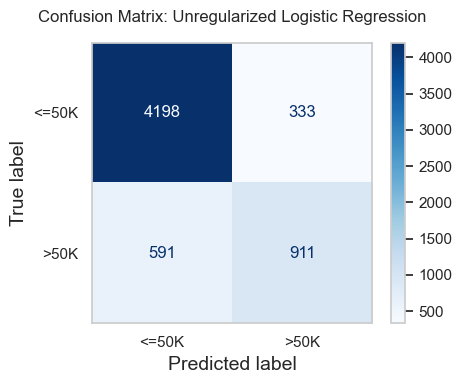

Executing Distributed Search: L2 Ridge Parameter Optimization...

EVALUATION PROFILE: L2 Regularized Logistic Regression (Ridge)
Optimal Hyperparameters : {'C': 0.1}
Training Wall-Time      : 4.0705 seconds
Inference Time          : 0.0000 seconds
Standard Accuracy       : 0.8458
Balanced Accuracy       : 0.7630
Matthews Corrcoef (MCC) : 0.5655



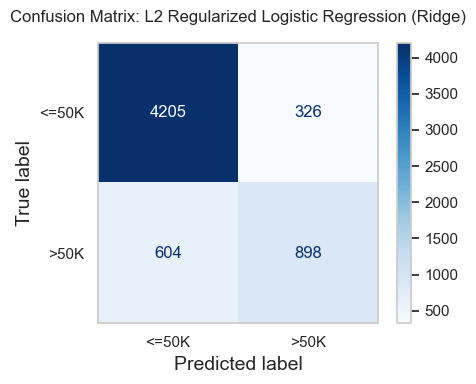

Executing Distributed Search: L1 LASSO Parameter Optimization...

EVALUATION PROFILE: L1 Regularized Logistic Regression (LASSO)
Optimal Hyperparameters : {'C': 1.0}
Training Wall-Time      : 5.8544 seconds
Inference Time          : 0.0000 seconds
Standard Accuracy       : 0.8467
Balanced Accuracy       : 0.7651
Matthews Corrcoef (MCC) : 0.5685



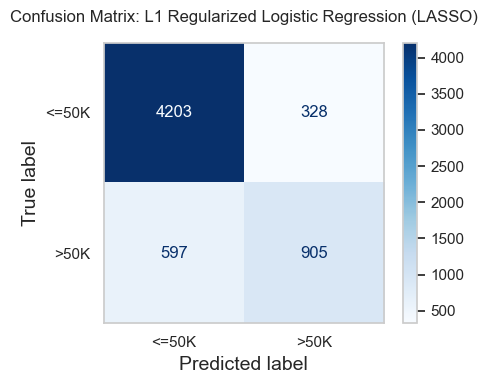

,estimator,"LogisticRegre...a', tol=0.001)"
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [5]:
# 1. Unregularized Parametric Baseline
# Demonstrates baseline capability before applying structural shrinkage constraints
unreg_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
evaluate_model(
    unreg_model, X_train_transformed, y_train, X_test_transformed, y_test, 
    model_name="Unregularized Logistic Regression"
)

# Define compact hyperparameter search grid targeting core transition phases
c_grid = {'C': [0.01, 0.1, 1.0, 10.0]}

# 2. Ridge (L2 Penalty)  Mitigates multicollinearity among highly specific dummy features
print("Executing Distributed Search: L2 Ridge Parameter Optimization...")
ridge_gs = GridSearchCV(
    LogisticRegression(solver='saga', penalty='l2', max_iter=2000, tol=1e-3),
    param_grid=c_grid, cv=3, n_jobs=-1
)
evaluate_model(
    ridge_gs, X_train_transformed, y_train, X_test_transformed, y_test, 
    model_name="L2 Regularized Logistic Regression (Ridge)"
)

# 3. LASSO (L1 Penalty)  Imposes sparsity to conduct feature selection automatically
print("Executing Distributed Search: L1 LASSO Parameter Optimization...")
lasso_gs = GridSearchCV(
    LogisticRegression(solver='saga', penalty='l1', max_iter=2000, tol=1e-3),
    param_grid=c_grid, cv=3, n_jobs=-1
)
evaluate_model(
    lasso_gs, X_train_transformed, y_train, X_test_transformed, y_test, 
    model_name="L1 Regularized Logistic Regression (LASSO)"
)

Extracting representative stratified subset (n=5,000) for fast hyperparameter tuning
Tuning Class Weighted Ridge pipeline on development subset
    Tuning Resolved. Optimal Hyperparameter C: 0.1

EVALUATION PROFILE: Class Weighted Ridge Final (C=0.1)
Training Wall-Time      : 0.0844 seconds
Inference Time          : 0.0000 seconds
Standard Accuracy       : 0.8064
Balanced Accuracy       : 0.8128
Matthews Corrcoef (MCC) : 0.5651



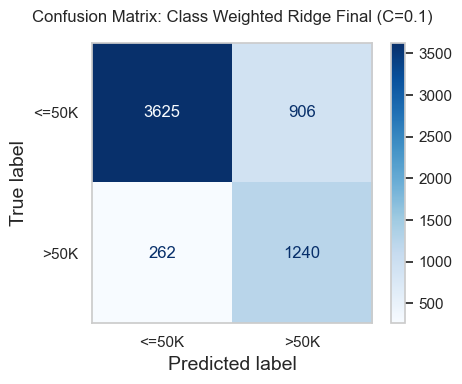

Tuning Class Weighted LASSO pipeline on development subset using MCC metric
    Tuning Resolved. Optimal Hyperparameter C: 1.0

EVALUATION PROFILE: Class Weighted LASSO Final (C=1.0)
Training Wall-Time      : 1.2680 seconds
Inference Time          : 0.0000 seconds
Standard Accuracy       : 0.8057
Balanced Accuracy       : 0.8124
Matthews Corrcoef (MCC) : 0.5641



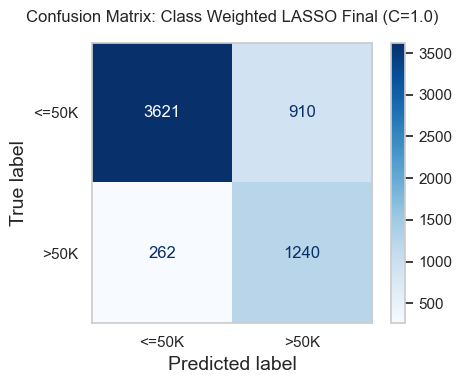

,penalty,'l1'
,dual,False
,tol,0.001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [6]:
# Strategic Subsampling: Isolate 5,000 samples to expedite grid cross validation
print("Extracting representative stratified subset (n=5,000) for fast hyperparameter tuning")
X_tune, y_tune = resample(
    X_train_transformed, y_train, 
    n_samples=5000, random_state=42, stratify=y_train
)

# Instantiate models configured to penalize minority misclassifications proportionally
weighted_ridge_base = LogisticRegression(
    solver='saga', penalty='l2', class_weight='balanced', max_iter=2000, tol=1e-3
)
weighted_lasso_base = LogisticRegression(
    solver='saga', penalty='l1', class_weight='balanced', max_iter=2000, tol=1e-3
)

#A. Optimized Class Weighted Ridge (Scored via Balanced Accuracy)
print("Tuning Class Weighted Ridge pipeline on development subset")
weighted_ridge_gs = GridSearchCV(
    weighted_ridge_base, param_grid=c_grid, cv=3, 
    scoring='balanced_accuracy', n_jobs=-1
)
weighted_ridge_gs.fit(X_tune, y_tune)
best_c_ridge = weighted_ridge_gs.best_params_['C']
print(f"    Tuning Resolved. Optimal Hyperparameter C: {best_c_ridge}")

# Fit production model natively on ENTIRE dataset using resolved parameter
final_weighted_ridge = LogisticRegression(
    solver='saga', penalty='l2', C=best_c_ridge, class_weight='balanced', max_iter=2000, tol=1e-3
)
evaluate_model(
    final_weighted_ridge, X_train_transformed, y_train, X_test_transformed, y_test,
    model_name=f"Class Weighted Ridge Final (C={best_c_ridge})"
)

#B. Optimized Class Weighted LASSO (Scored via Custom MCC Scorer)
print("Tuning Class Weighted LASSO pipeline on development subset using MCC metric")
mcc_scorer = make_scorer(matthews_corrcoef)

weighted_lasso_gs = GridSearchCV(
    weighted_lasso_base, param_grid=c_grid, cv=3, 
    scoring=mcc_scorer, n_jobs=-1
)
weighted_lasso_gs.fit(X_tune, y_tune)
best_c_lasso = weighted_lasso_gs.best_params_['C']
print(f"    Tuning Resolved. Optimal Hyperparameter C: {best_c_lasso}")

# Fit production model natively on ENTIRE dataset using resolved parameter
final_weighted_lasso = LogisticRegression(
    solver='saga', penalty='l1', C=best_c_lasso, class_weight='balanced', max_iter=2000, tol=1e-3
)
evaluate_model(
    final_weighted_lasso, X_train_transformed, y_train, X_test_transformed, y_test,
    model_name=f"Class Weighted LASSO Final (C={best_c_lasso})"
)

In [7]:
# Verify model contains learned parameters before extraction
if hasattr(final_weighted_lasso, 'coef_'):
    # Extract feature names generated by Scikit Learn's ColumnTransformer pipeline
    feature_names = preprocessor.get_feature_names_out()
    coefficients = final_weighted_lasso.coef_[0]
    
    # Map coefficients to data frame for structural clarity
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Absolute_Weight': np.abs(coefficients)
    }).sort_values(by='Absolute_Weight', ascending=False).reset_index(drop=True)
    
    print('\n')
    print("TOP 10 MOST INFLUENTIAL LOGISTIC REGRESSION WEIGHTS (LASSO)")
    print("="*60)
    print(coef_df.head(10).to_string(index=False))
    
    # Quick sanity check on L1 Feature Dropping (Sparsity)
    zero_weights = (coef_df['Coefficient'] == 0).sum()
    print(f"\nSparsity Profile: LASSO completely zeroed out {zero_weights} redundant features.")



TOP 10 MOST INFLUENTIAL LOGISTIC REGRESSION WEIGHTS (LASSO)
                                Feature  Coefficient  Absolute_Weight
       cat__occupation_ Priv-house-serv    -2.511915         2.511915
                      num__capital_gain     2.503721         2.503721
                       cat__sex_ Female    -1.638592         1.638592
cat__marital_status_ Married-civ-spouse     1.562574         1.562574
          cat__native_country_ Columbia    -1.421197         1.421197
                cat__relationship_ Wife     1.224762         1.224762
cat__native_country_ Dominican-Republic    -1.173407         1.173407
 cat__marital_status_ Married-AF-spouse     1.141160         1.141160
           cat__relationship_ Own-child    -1.130256         1.130256
            cat__workclass_ Without-pay    -1.129904         1.129904

Sparsity Profile: LASSO completely zeroed out 19 redundant features.
